# Gemma 3 vs Gemma 4: Road Sign Text Recognition
**CS153 Final Project**
**Janav Shah & Florence Lin**

In [1]:
import os, sys, re
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

filepath = "/cs/cs153/projects/jshah/cv153_final_project"
sys.path.insert(0, filepath)
from config import DS1_LABELS, PROCESSED_DIR, PREDS_DIR, METRICS_DIR, TEXT_SIGNS

print("Setup complete.")
print("TEXT_SIGNS count:", len(TEXT_SIGNS))

Setup complete.
TEXT_SIGNS count: 17


## Dataset Sample Images with Ground Truth Labels

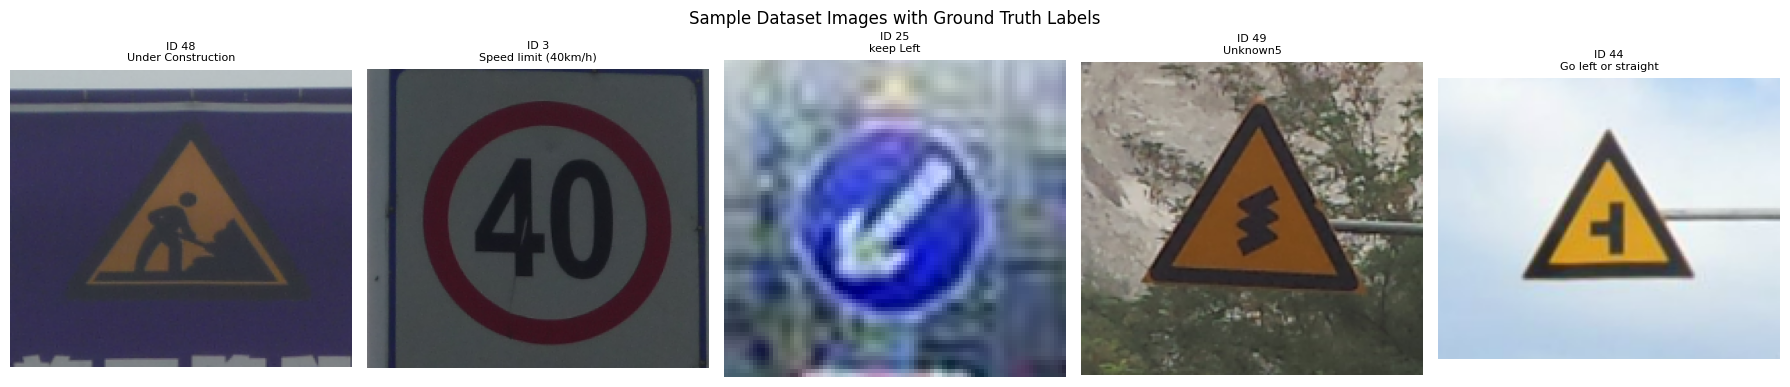

In [13]:
meta_df = pd.read_csv(os.path.join(PROCESSED_DIR, "eval_metadata.csv"))
sample = meta_df.sample(5, random_state=42)
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, (_, row) in zip(axes, sample.iterrows()):
    img = Image.open(row["image_path"]).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"ID {row['class_id']}\n{row['label_name']}", fontsize=8)
    ax.axis("off")
fig.suptitle("Sample Dataset Images with Ground Truth Labels", fontsize=12)
plt.tight_layout()
plt.show()

## The Pipeline

Each image is passed to both models with the same prompt and then the model outputs a string which we compare to the ground truth label using exact match and BLEU score

**Prompt for text extraction:** *What text is written on this road sign? Reply with only the text you see, nothing else.*

**Prompt for meaning:** *What does this road sign mean? Reply with one short sentence.*

In [14]:
# Load our already computed predictions
g3 = pd.read_csv(os.path.join(PREDS_DIR, "gemma3_text_extraction.csv"))
g4 = pd.read_csv(os.path.join(PREDS_DIR, "gemma4_text_extraction.csv"))

# Fix the column name
if "pred_1" in g3.columns: g3 = g3.rename(columns={"pred_1": "prediction"})
if "pred_1" in g4.columns: g4 = g4.rename(columns={"pred_1": "prediction"})

print(f"Gemma 3 predictions loaded: {len(g3)} images")
print(f"Gemma 4 predictions loaded: {len(g4)} images")
print()
print("Sample predictions:")
for _, row in g3.head(5).iterrows():
    g4_pred = g4[g4["class_id"] == row["class_id"]]["prediction"].values
    g4_str  = g4_pred[0] if len(g4_pred) > 0 else "N/A"
    print(f"  GT: {row['label_name']:<30} G3: {str(row['prediction']):<25} G4: {g4_str}")

Gemma 3 predictions loaded: 171 images
Gemma 4 predictions loaded: 171 images

Sample predictions:
  GT: Unknown8                       G3: 检查                        G4: 検査
  GT: Unknown2                       G3: Caution                   G4: No text is visible on the road sign.
  GT: Bicycles crossing              G3: There is no text on the sign. G4: There is no text written on this road sign.
  GT: Dont Go straight or Right      G3: No Right Turn             G4: I cannot read any text on the road sign because the image is too blurry.
  GT: Traffic signals                G3: Traffic Lights            G4: No text is visible on this road sign.


## Scoring With Exact Match & BLEU

In [15]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
_sf = SmoothingFunction().method1

def norm(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", "", text)
    return re.sub(r"\s+", " ", text).strip()

def exact_match(pred, label):
    if "km/h" in str(label).lower():
        nums = re.findall(r"\d+", str(label))
        return any(n in str(pred) for n in nums)
    return norm(label) in norm(str(pred))

def bleu(pred, ref):
    r = norm(ref).split()
    h = norm(str(pred)).split()
    return round(sentence_bleu([r], h, smoothing_function=_sf), 4) if h and r else 0.0

def score(df, model_name):
    df = df.copy()
    df["model"] = model_name
    df["sign_type"] = df["label_name"].apply(lambda x: "text" if x in TEXT_SIGNS else "symbol")
    df["exact_match"] = df.apply(lambda r: exact_match(r["prediction"], r["label_name"]), axis=1)
    df["bleu_score"]  = df.apply(lambda r: bleu(r["prediction"], r["label_name"]), axis=1)
    return df

g3_scored = score(g3, "Gemma 3")
g4_scored = score(g4, "Gemma 4")

## Results

In [16]:
merged = g3_scored[["label_name", "sign_type", "prediction", "exact_match", "bleu_score"]].copy()
merged.columns = ["Ground Truth", "Sign Type", "Gemma 3 Output", "G3 Match", "G3 BLEU"]
merged["Gemma 4 Output"] = g4_scored["prediction"].values
merged["G4 Match"] = g4_scored["exact_match"].values
merged["G4 BLEU"] = g4_scored["bleu_score"].values
print(merged.sample(10, random_state=42).to_string(index=False))

           Ground Truth Sign Type                                                                     Gemma 3 Output  G3 Match  G3 BLEU                                                           Gemma 4 Output  G4 Match  G4 BLEU
     Under Construction      text                                                                                NaN     False      0.0                                                                   *URBAN     False   0.0000
   Speed limit (40km/h)      text                                                                                 40      True      0.0                                                                       40      True   0.0000
              keep Left    symbol                                                                               Turn     False      0.0 I cannot read any text on the road sign because the image is too blurry.     False   0.0000
               Unknown5    symbol There is no text written on the sign. It only contains

## Aggregated Results

In [17]:
def summarize(df):
    rows = []
    for subset, sub in [("All Signs", df), ("Text Signs",   df[df["sign_type"]=="text"]), ("Symbol Signs", df[df["sign_type"]=="symbol"])]:
        rows.append({
            "Model":df["model"].iloc[0],
            "Subset":subset,
            "N":len(sub),
            "Exact Match %":round(sub["exact_match"].mean() * 100, 1),
            "Avg BLEU":round(sub["bleu_score"].mean(), 4),
        })
    return pd.DataFrame(rows)
summary = pd.concat([summarize(g3_scored), summarize(g4_scored)], ignore_index=True)
print(summary.to_string(index=False))

  Model       Subset   N  Exact Match %  Avg BLEU
Gemma 3    All Signs 171           21.1    0.0269
Gemma 3   Text Signs  56           60.7    0.0373
Gemma 3 Symbol Signs 115            1.7    0.0218
Gemma 4    All Signs 171           17.5    0.0027
Gemma 4   Text Signs  56           53.6    0.0064
Gemma 4 Symbol Signs 115            0.0    0.0009


## Failure

In [18]:
def failure_type(pred, label):
    if exact_match(pred, label):
        return "correct"
    p = norm(str(pred))
    if "no text" in p or "not visible" in p or "no text is visible" in p:
        return "refused (no text)"
    if any(w in p for w in norm(str(label)).split() if len(w) > 3):
        return "partial match"
    return "hallucinated / wrong"

g3_scored["failure_type"] = g3_scored.apply(lambda r: failure_type(r["prediction"], r["label_name"]), axis=1)
g4_scored["failure_type"] = g4_scored.apply(lambda r: failure_type(r["prediction"], r["label_name"]), axis=1)

for name, df in [("Gemma 3", g3_scored), ("Gemma 4", g4_scored)]:
    print(f"\n{name}:")
    for k, v in df["failure_type"].value_counts().items():
        print(f"  {k:<30} {v:>4}  ({v/len(df)*100:.1f}%)")


Gemma 3:
  hallucinated / wrong             84  (49.1%)
  correct                          36  (21.1%)
  refused (no text)                35  (20.5%)
  partial match                    16  (9.4%)

Gemma 4:
  refused (no text)                96  (56.1%)
  hallucinated / wrong             45  (26.3%)
  correct                          30  (17.5%)
